<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Core Validation 1 - PMNS, Mass Spectrum and Matter Potential
---
This notebook validates the physical building blocks of `tpeanuts.core.common` and `tpeanuts.core.SM` that feed the propagation Hamiltonian. Every claim is checked against a closed-form expression or an internal consistency identity. Four validation blocks are covered:

1. PMNS unitarity, the Jarlskog CP-violation invariant, the neutrino/antineutrino conjugation convention, and the vacuum flavour projector;
2. the active-sector mass-squared difference vector and its normal/inverted ordering conventions;
3. the charged-current, neutral-current, and kinetic potentials, cross-checked against a known reference formula and internal linearity/sign identities;
4. the density scale at which the matter and kinetic terms become comparable, thereby identifying the MSW-resonance scale.

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-PMNS-Mixing-Matrix) | **PMNS Mixing Matrix** |
| [4](#4.-Mass-Squared-Spectrum) | **Mass-Squared Spectrum** |
| [5](#5.-Matter-and-Kinetic-Potentials) | **Matter and Kinetic Potentials** |
| [6](#6.-Summary) | **Summary** |


## 0. Theoretical Framework
---

### 0.1 The PMNS mixing matrix

Flavour and mass eigenstates are related by the Pontecorvo-Maki-Nakagawa-Sakata matrix [1,2],

$$|\nu_\alpha\rangle=\sum_{i=1}^{3}U^*_{\alpha i}|\nu_i\rangle,\qquad U=R_{23}\,\Delta\,R_{13}\,\Delta^\dagger\,R_{12},\qquad \Delta=\mathrm{diag}(1,1,e^{i\delta_{\rm CP}}),$$

with $R_{ij}$ the real rotation in the $(i,j)$ plane by mixing angle $\theta_{ij}$. This is exactly the product structure built by `PMNS_SM.pmns_matrix`. Neutrino and antineutrino propagation differ only by $U\to U^*$ (equivalently $\delta_{\rm CP}\to-\delta_{\rm CP}$), the standard CP-conjugation convention [3].




### 0.2 The Jarlskog invariant

CP violation in the lepton sector is captured by a single rephasing-invariant combination, the Jarlskog invariant [3],

$$J=\mathrm{Im}\!\left[U_{e1}U_{\mu2}U^*_{e2}U^*_{\mu1}\right]=\frac{1}{8}\sin2\theta_{12}\sin2\theta_{13}\sin2\theta_{23}\cos\theta_{13}\sin\delta_{\rm CP}.$$

$J$ vanishes for $\delta_{\rm CP}\in\{0,\pi\}$ (CP conservation) and is odd under $\delta_{\rm CP}\to-\delta_{\rm CP}$.


### 0.3 Active-sector mass-squared spectrum

Two independent splittings, $\Delta m^2_{21}$ (solar) and $\Delta m^2_{3\ell}$ (atmospheric, $\ell=1$ for normal ordering NO, $\ell=2$ for inverted ordering IO), fully determine the active mass-squared vector relative to the lightest state [4]:

$$\text{NO }(\Delta m^2_{3\ell}>0):\ (m_1^2,m_2^2,m_3^2)-m_1^2=(0,\ \Delta m^2_{21},\ \Delta m^2_{3\ell}),$$
$$\text{IO }(\Delta m^2_{3\ell}<0):\ (m_1^2,m_2^2,m_3^2)-m_2^2=(-\Delta m^2_{21},\ 0,\ \Delta m^2_{3\ell}).$$


### 0.4 Matter and kinetic potentials

Coherent forward scattering of $\nu_e$ off electrons gives the Wolfenstein charged-current potential [5], and forward scattering off neutrons (relevant only once a neutral-current-blind sterile state is present) gives the neutral-current potential:

$$V_{\rm CC}=s\sqrt{2}\,G_F\,n_e,\qquad V_{\rm NC}=-s\,\frac{1}{\sqrt2}G_F\,n_n,\qquad s=+1\ (\nu),\ -1\ (\bar\nu).$$

A commonly quoted numerical form for the charged-current potential, for electron fraction $Y_e$ and mass density $\rho$, is [3]

$$V_{\rm CC}\simeq 7.63\times10^{-14}\,\rho[\mathrm{g/cm^3}]\,Y_e\ \mathrm{eV}.$$

The vacuum (kinetic) term contributes the usual oscillation phase,

$$V_{\rm kin,i}=\frac{\Delta m^2_{i1}}{2E}\quad\text{(natural units)},$$

implemented dimensionlessly as `evolution_scale_m * mSq * 1e-12 / (2E) / HBARC_MeV_m` so it combines directly with `V_CC`/`V_NC` inside the reduced propagation Hamiltonian.




### 0.5 Common simulation configuration

| Parameter | Value |
|---|---|
| Oscillation preset / ordering | `_SM_NUFIT52_NO` / normal ordering [4] |
| $\theta_{12},\theta_{13},\theta_{23}$ | NuFIT 5.2 best fit |
| $\delta_{\rm CP}$ | NuFIT 5.2 best fit |
| Evolution scale | Earth radius $R_E$ |
| Device / dtype | Runtime-resolved values printed below |

**References**

- [1] B. Pontecorvo, Zh. Eksp. Teor. Fiz. **33**, 549 (1957); ibid. **53**, 1717 (1967).
- [2] Z. Maki, M. Nakagawa, S. Sakata, *Prog. Theor. Phys.* **28**, 870 (1962).
- [3] Giunti, C., & Kim, C. W. (2007). *Fundamentals of Neutrino Physics and Astrophysics*. Oxford University Press.
- [4] Esteban, I. et al. (2020). The fate of hints: updated global analysis of three-flavor neutrino oscillations. *JHEP* **09**, 178, [arXiv:2007.14792](https://arxiv.org/abs/2007.14792); NuFIT 5.2 release (2022).
- [5] Wolfenstein, L. (1978). Neutrino oscillations in matter. *Phys. Rev. D* **17**, 2369.




## 1. Libraries


In [1]:
from __future__ import annotations
%matplotlib inline
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy, FLAVOUR_LABELS

from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.core.common.pmns import PMNSParams
from tpeanuts.core.SM.sm_pmns import PMNS_SM
from tpeanuts.core.SM.sm_mass_spectrum import MassSpectrum_SM
from tpeanuts.core.common.potential import matter_potential_cc, matter_potential_nc, kinetic_potential
from tpeanuts.util.context import RuntimeContext
import tpeanuts.util.constant as constant

## 2. Paths and Configuration


### 2.1 Paths

`load_notebook_config()` resolves the package directory and applies the shared plotting/Torch/NumPy style. Following the notebook-relative convention, generated figures and tables are saved under `analysis/core/`.

In [2]:
config = load_notebook_config()
DEVICE, DTYPE = config.device, config.dtype
context = RuntimeContext.resolve(DEVICE, DTYPE)
OUTPUT_DIR = config.output_dir('analysis', 'core')

print(f'Package dir : {config.package_dir}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Device      : {context.device}   dtype: {context.dtype}')

Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\analysis\core
Device      : cuda:0   dtype: torch.float64


### 2.2 Configuration

The NuFIT 5.2 normal-ordering preset [4] supplies $\theta_{12},\theta_{13},\theta_{23},\delta_{\rm CP}$ and $\Delta m^2_{21},\Delta m^2_{3\ell}$. `PMNS_SM`/`MassSpectrum_SM` are rebuilt directly (not only through the preset) in Sections 3-4 whenever a parameter needs to be swept (e.g. $\delta_{\rm CP}$, or the sign of $\Delta m^2_{3\ell}$ for the ordering comparison), so the configuration below is the shared *reference* point, not the only parameter set evaluated.

**Expected results:** <br>
- The printed table reports the actual NuFIT values in degrees/eV$^2$ together with the runtime device and dtype.



In [3]:
oscillation = PropagationConfig.oscillation_parameters_from_preset('_SM_NUFIT52_NO', antinu=False, context=context)
oscillation_bar = PropagationConfig.oscillation_parameters_from_preset('_SM_NUFIT52_NO', antinu=True, context=context)
pmns = oscillation.pmns

configuration_rows = [
    ('theta12 [deg]', math.degrees(float(pmns.params.theta12))),
    ('theta13 [deg]', math.degrees(float(pmns.params.theta13))),
    ('theta23 [deg]', math.degrees(float(pmns.params.theta23))),
    ('delta_CP [deg]', math.degrees(float(pmns.params.delta))),
    ('Delta m^2_21 [eV^2]', float(oscillation.mass_spectrum.DeltamSq21)),
    ('Delta m^2_3l [eV^2]', float(oscillation.mass_spectrum.DeltamSq3l)),
    ('Ordering', oscillation.ordering),
    ('Evolution scale R_E [m]', constant.R_E),
    ('Device', str(context.device)),
    ('Real dtype', str(context.dtype)),
]
display(pd.DataFrame(configuration_rows, columns=['Parameter', 'Value']))

,Parameter,Value
0,theta12 [deg],33.41
1,theta13 [deg],8.58
2,theta23 [deg],49.0
3,delta_CP [deg],197.0
4,Delta m^2_21 [eV^2],0.000074
5,Delta m^2_3l [eV^2],0.002511
6,Ordering,NO
7,Evolution scale R_E [m],6371000.0
8,Device,cuda:0
9,Real dtype,torch.float64


### 2.3 Local Helpers

A single small helper builds a `PMNS_SM` from explicit angles (used repeatedly in Section 3 to scan $\delta_{\rm CP}$ and to probe the CP-conserving limit); everything else reuses `tpeanuts.notebooks.notebooks_helper` or is a direct one-line call to the `core` API under test.


In [4]:
def make_pmns(theta12, theta13, theta23, delta, *, context=context):
    params = PMNSParams(theta12=theta12, theta13=theta13, theta23=theta23, delta=delta, context=context)
    return PMNS_SM(params)

def V_cc_eV(n_e_mol_cm3):
    V_dimensionless = matter_potential_cc(torch.tensor(n_e_mol_cm3, dtype=context.dtype), False, evolution_scale_m=constant.R_E, context=context)
    return float(V_dimensionless) * constant.HBARC_MeV_m / constant.R_E * 1.0e6  # MeV -> eV

def unitarity_residual(pmns_obj, antinu=False):
    U = pmns_obj.pmns_matrix(antinu=antinu)
    I = torch.eye(3, device=U.device, dtype=U.dtype)
    left = torch.max(torch.abs(U.conj().transpose(-2, -1) @ U - I))
    right = torch.max(torch.abs(U @ U.conj().transpose(-2, -1) - I))
    return float(torch.maximum(left, right))


## 3. PMNS Mixing Matrix

### 3.1 Unitarity

$U$ must satisfy $U^\dagger U=UU^\dagger=\mathbb{1}$ exactly, for both the NuFIT best fit and an arbitrary parameter point.

**Expected results:**<br>
- The computed unitarity observables are finite, dimensionally consistent, and stable on the stated numerical grid.
- Probability or flux normalization is preserved within the accuracy implied by the selected method.
- Both products equal the identity to floating-point precision ($\lesssim10^{-14}$).
- This holds independently of $\delta_{\rm CP}$ and of the neutrino/antineutrino convention.


In [5]:

random_pmns = make_pmns(0.61, 0.23, 0.79, 2.4)
rows = [
    ('NuFIT best fit, nu', unitarity_residual(pmns, antinu=False)),
    ('NuFIT best fit, nubar', unitarity_residual(pmns, antinu=True)),
    ('Arbitrary angles, nu', unitarity_residual(random_pmns, antinu=False)),
]
unitarity_table = pd.DataFrame(rows, columns=['Case', 'max|U^dagger U - I|'])
display(unitarity_table.style.format({'max|U^dagger U - I|': '{:.3e}'}))
assert unitarity_table['max|U^dagger U - I|'].max() < 1.0e-12


,Case,max|U^dagger U - I|
0,"NuFIT best fit, nu",1.110e-16
1,"NuFIT best fit, nubar",1.110e-16
2,"Arbitrary angles, nu",2.221e-16


### 3.2 Jarlskog invariant versus the closed-form expression

`pmns.jarlskog_invariant()` is compared against the closed-form product formula of Section 0.2 over a full $\delta_{\rm CP}$ scan at fixed NuFIT mixing angles.

**Expected results:**<br>
- The two curves overlap within floating-point precision at every $\delta_{\rm CP}$.
- $J=0$ at $\delta_{\rm CP}\in\{0,\pi\}$ and $J(-\delta_{\rm CP})=-J(\delta_{\rm CP})$.


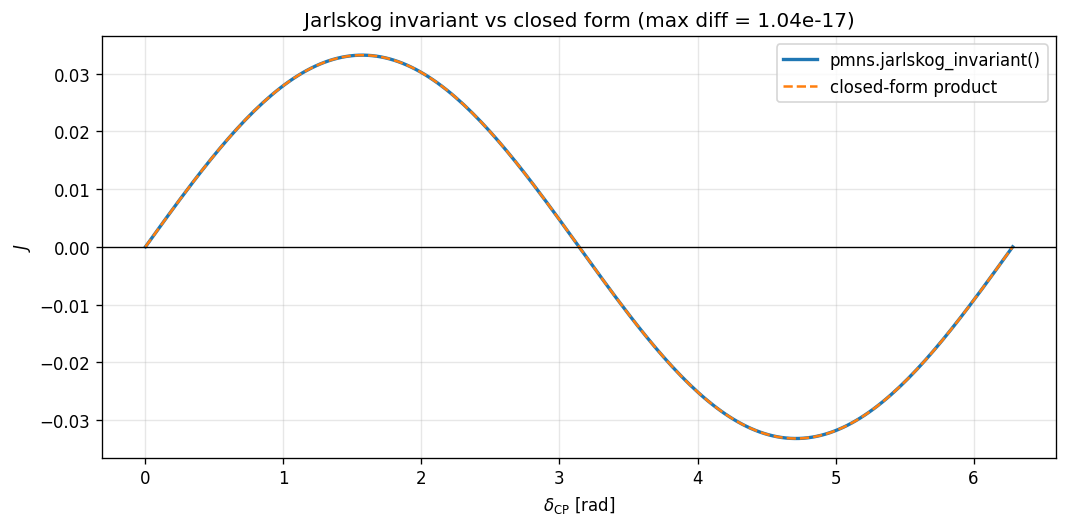

v:\output\analysis\core\core1_fig32_jarlskog_vs_delta.png
max|J_code - J_formula|   = 1.041e-17
J(delta=0)                = -0.000e+00
J(delta=pi)               = 4.065e-18
J(0.7) + J(-0.7)          = 0.000e+00  (antisymmetry)


In [6]:
delta_scan = torch.linspace(0.0, 2 * math.pi, 200, device=context.device, dtype=context.dtype)
t12, t13, t23 = (float(getattr(pmns.params, name)) for name in ('theta12', 'theta13', 'theta23'))

J_code = torch.stack([make_pmns(t12, t13, t23, d).jarlskog_invariant() for d in delta_scan])
J_formula = 0.125 * math.sin(2 * t12) * math.sin(2 * t13) * math.sin(2 * t23) * math.cos(t13) * torch.sin(delta_scan)
max_diff = float(torch.max(torch.abs(J_code - J_formula)))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(to_numpy(delta_scan), to_numpy(J_code), label='pmns.jarlskog_invariant()', lw=2)
ax.plot(to_numpy(delta_scan), to_numpy(J_formula), '--', label='closed-form product', lw=1.5)
ax.axhline(0.0, color='k', lw=0.8)
ax.set_xlabel(r'$\delta_{\rm CP}$ [rad]')
ax.set_ylabel(r'$J$')
ax.set_title(f'Jarlskog invariant vs closed form (max diff = {max_diff:.2e})')
ax.legend()
fig.tight_layout()
save_and_show('core1_fig32_jarlskog_vs_delta.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

J_at_0 = float(make_pmns(t12, t13, t23, 0.0).jarlskog_invariant())
J_at_pi = float(make_pmns(t12, t13, t23, math.pi).jarlskog_invariant())
J_plus = float(make_pmns(t12, t13, t23, 0.7).jarlskog_invariant())
J_minus = float(make_pmns(t12, t13, t23, -0.7).jarlskog_invariant())
print(f'max|J_code - J_formula|   = {max_diff:.3e}')
print(f'J(delta=0)                = {J_at_0:.3e}')
print(f'J(delta=pi)               = {J_at_pi:.3e}')
print(f'J(0.7) + J(-0.7)          = {J_plus + J_minus:.3e}  (antisymmetry)')
assert max_diff < 1.0e-12
assert abs(J_at_0) < 1.0e-12 and abs(J_at_pi) < 1.0e-12
assert abs(J_plus + J_minus) < 1.0e-12

### 3.3 Neutrino/antineutrino conjugation

`pmns_matrix(antinu=True)` must equal the elementwise complex conjugate of `pmns_matrix(antinu=False)`, and -- as an independent cross-check -- must also equal the matrix rebuilt with $\delta_{\rm CP}\to-\delta_{\rm CP}$, since $U\to U^*$ and $\delta_{\rm CP}\to-\delta_{\rm CP}$ are the same physical CP transformation for the standard parametrisation.

**Expected results:**<br>
- `pmns_matrix(antinu=True)` matches `pmns_matrix(antinu=False).conj()` exactly.
- It also matches a fresh `PMNS_SM` built with $-\delta_{\rm CP}$, to floating-point precision.

In [7]:
U_nu = pmns.pmns_matrix(antinu=False)
U_nubar = pmns.pmns_matrix(antinu=True)
U_neg_delta = make_pmns(t12, t13, float(pmns.params.theta23), -float(pmns.params.delta)).pmns_matrix(antinu=False)

diff_conj = float(torch.max(torch.abs(U_nubar - U_nu.conj())))
diff_negdelta = float(torch.max(torch.abs(U_nubar - U_neg_delta)))
print(f'max|U(nubar) - U(nu)^*|            = {diff_conj:.3e}')
print(f'max|U(nubar) - U(-delta_CP)|       = {diff_negdelta:.3e}')
assert diff_conj < 1.0e-14
assert diff_negdelta < 1.0e-12

max|U(nubar) - U(nu)^*|            = 0.000e+00
max|U(nubar) - U(-delta_CP)|       = 0.000e+00


### 3.4 Vacuum flavour projector

The decohered projector $|U_{\alpha i}|^2$ (`pmns.vacuum_flavour_projector`) is doubly stochastic: both its rows (fixed flavour, summed over mass) and its columns (fixed mass eigenstate, summed over flavour) sum to one, since $U$ is unitary.

**Expected results:**<br>
- Every row sum and column sum equals 1 to floating-point precision.
- The heatmap shows $\nu_e$ dominated by mass state 1, consistent with small $\theta_{13}$.


row sums (flavour): [1. 1. 1.]
col sums (mass eigenstate): [1. 1. 1.]


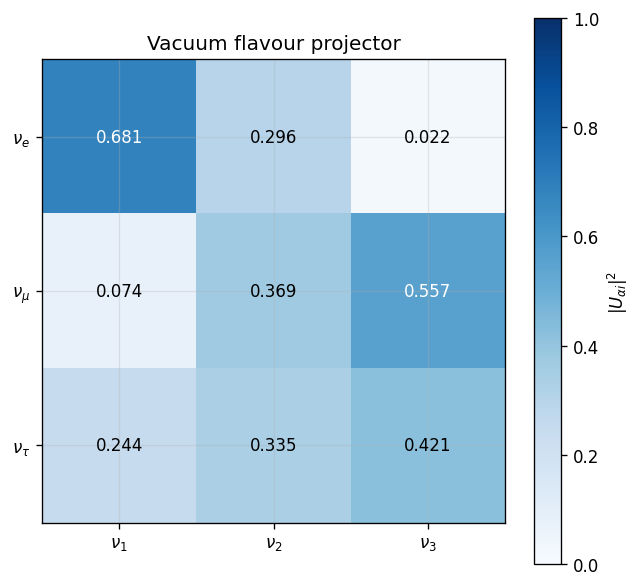

v:\output\analysis\core\core1_fig34_flavour_projector.png


In [8]:
proj = to_numpy(pmns.vacuum_flavour_projector())
row_sums = proj.sum(axis=1)
col_sums = proj.sum(axis=0)
print('row sums (flavour):', row_sums)
print('col sums (mass eigenstate):', col_sums)
assert np.allclose(row_sums, 1.0, atol=1e-12)
assert np.allclose(col_sums, 1.0, atol=1e-12)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(proj, vmin=0.0, vmax=1.0, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels([r'$\nu_1$', r'$\nu_2$', r'$\nu_3$'])
ax.set_yticks(range(3)); ax.set_yticklabels(FLAVOUR_LABELS)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{proj[i, j]:.3f}', ha='center', va='center', color='white' if proj[i, j] > 0.5 else 'black')
fig.colorbar(im, ax=ax, label=r'$|U_{\alpha i}|^2$')
ax.set_title('Vacuum flavour projector')
fig.tight_layout()
save_and_show('core1_fig34_flavour_projector.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 4. Mass-Squared Spectrum

### 4.1 Difference-vector consistency

`MassSpectrum_SM.difference_vector()` builds $(m_1^2,m_2^2,m_3^2)$ relative to the lightest state (Section 0.3). For normal ordering, the vector must reproduce $\Delta m^2_{21}$ and $\Delta m^2_{31}=\Delta m^2_{3\ell}$ exactly by construction, and the derived splitting $\Delta m^2_{32}=\Delta m^2_{31}-\Delta m^2_{21}$ must match NuFIT's separate atmospheric splitting for the antineutrino sector (same numerical value here since both come from the same preset).

**Expected results:**
- $m_2^2-m_1^2=\Delta m^2_{21}$ and $m_3^2-m_1^2=\Delta m^2_{3\ell}$ exactly.
- $\Delta m^2_{32}=\Delta m^2_{31}-\Delta m^2_{21}$ holds to floating-point precision.

In [9]:
mass_spectrum_NO = oscillation.mass_spectrum
vec_NO = mass_spectrum_NO.difference_vector(context=context)
dm21 = float(mass_spectrum_NO.DeltamSq21)
dm3l = float(mass_spectrum_NO.DeltamSq3l)

m21_check = float(vec_NO[1] - vec_NO[0])
m31_check = float(vec_NO[2] - vec_NO[0])
m32_check = float(vec_NO[2] - vec_NO[1])
print(f'vector (m_i^2 - m_1^2)  = {to_numpy(vec_NO)}')
print(f'm2^2 - m1^2 vs Dm21     : {m21_check:.6e} vs {dm21:.6e}')
print(f'm3^2 - m1^2 vs Dm3l     : {m31_check:.6e} vs {dm3l:.6e}')
print(f'm3^2 - m2^2 (Dm32)      : {m32_check:.6e}  (= Dm31 - Dm21 = {dm3l - dm21:.6e})')
assert abs(m21_check - dm21) < 1.0e-20
assert abs(m31_check - dm3l) < 1.0e-20
assert abs(m32_check - (dm3l - dm21)) < 1.0e-20

vector (m_i^2 - m_1^2)  = [0.000e+00 7.410e-05 2.511e-03]
m2^2 - m1^2 vs Dm21     : 7.410000e-05 vs 7.410000e-05
m3^2 - m1^2 vs Dm3l     : 2.511000e-03 vs 2.511000e-03
m3^2 - m2^2 (Dm32)      : 2.436900e-03  (= Dm31 - Dm21 = 2.436900e-03)


### 4.2 Normal versus inverted ordering

An inverted-ordering spectrum is obtained by flipping the sign of $\Delta m^2_{3\ell}$ (the code's own NO/IO convention, Section 0.3), keeping $\Delta m^2_{21}$ fixed. The resulting level diagrams show the qualitatively different mass hierarchies.

**Expected results:**
- NO: $m_3$ is the heaviest state, well separated from the near-degenerate $(m_1,m_2)$ pair.
- IO: $m_3$ is the lightest state, well separated from the near-degenerate $(m_1,m_2)$ pair.
- Both spectra share the same $\Delta m^2_{21}$ splitting between their near-degenerate pair.


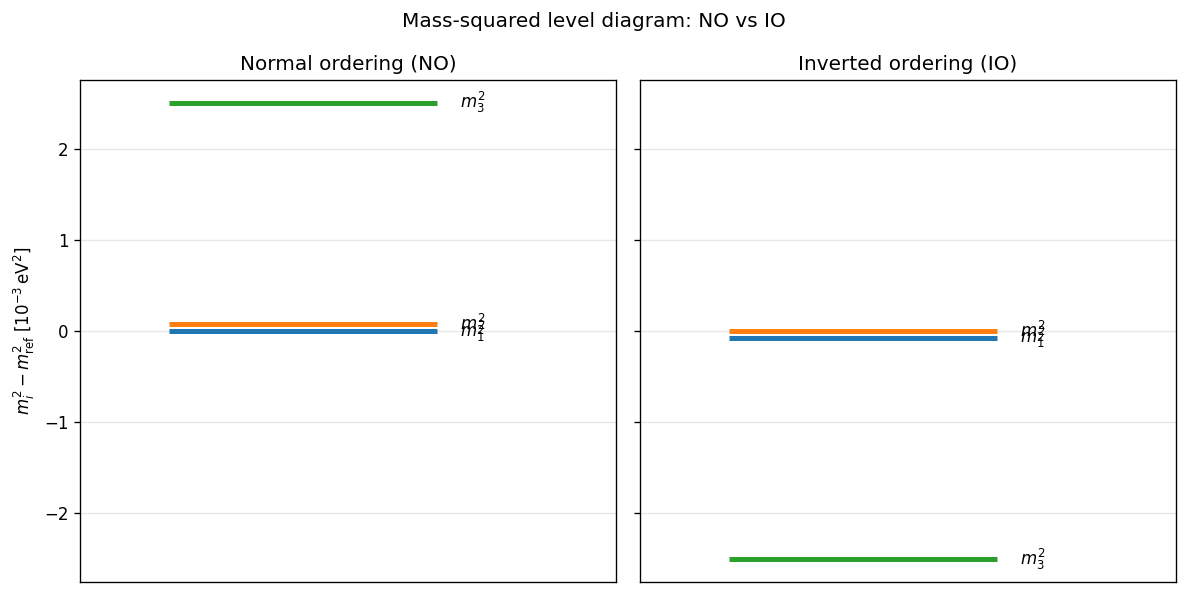

v:\output\analysis\core\core1_fig42_no_vs_io_levels.png
NO vector [eV^2]: [0.000e+00 7.410e-05 2.511e-03]
IO vector [eV^2]: [-7.410e-05  0.000e+00 -2.511e-03]


In [10]:
mass_spectrum_IO = MassSpectrum_SM(DeltamSq21=mass_spectrum_NO.DeltamSq21, DeltamSq3l=-mass_spectrum_NO.DeltamSq3l)
vec_IO = mass_spectrum_IO.difference_vector(context=context)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for ax, vec, label in zip(axes, (vec_NO, vec_IO), ('Normal ordering (NO)', 'Inverted ordering (IO)')):
    levels = to_numpy(vec) * 1.0e3  # eV^2 -> meV^2 for readability
    for i, level in enumerate(levels):
        ax.hlines(level, 0.2, 0.8, color=f'C{i}', lw=3)
        ax.text(0.85, level, f'$m_{i + 1}^2$', va='center')
    ax.set_title(label)
    ax.set_xlim(0, 1.2)
    ax.set_xticks([])
axes[0].set_ylabel(r'$m_i^2 - m_{\rm ref}^2$ [$10^{-3}\,\mathrm{eV}^2$]')
fig.suptitle('Mass-squared level diagram: NO vs IO')
fig.tight_layout()
save_and_show('core1_fig42_no_vs_io_levels.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print('NO vector [eV^2]:', to_numpy(vec_NO))
print('IO vector [eV^2]:', to_numpy(vec_IO))
assert float(vec_NO[2]) > float(vec_NO[1]) > float(vec_NO[0])  # NO: m3 heaviest
assert float(vec_IO[2]) < float(vec_IO[0]) < float(vec_IO[1])  # IO: m3 lightest

## 5. Matter and Kinetic Potentials

This stage defines and evaluates matter and kinetic potentials.

### 5.1 Charged-current potential versus a known reference formula

`matter_potential_cc` is converted from its dimensionless form back to physical eV ($V=\hat V\cdot\mathrm{HBARC\_MeV\_m}/\mathrm{evolution\_scale\_m}\times10^6$) and compared with the textbook numerical rule $V_{\rm CC}\simeq7.63\times10^{-14}\,\rho\,Y_e\,\mathrm{eV}$ (Section 0.4), using the real bundled PREM density table at the Earth's core and crust. The neutron-neutral-current potential's ratio to $V_{\rm CC}$ at equal density, and the antineutrino sign flip, are checked directly against the code's own normalization (Section 0.4).

**Expected results:**
- The code and the textbook rule agree to better than 1% at both reference densities.
- $V_{\rm NC}/V_{\rm CC}=-1/2$ exactly at equal electron/neutron density.
- $V_{\rm CC}(\bar\nu)=-V_{\rm CC}(\nu)$ exactly.



In [11]:
prem = pd.read_csv(config.prem_density_file)
core_row = prem.loc[prem['electron_density_mol_cm3'].idxmax()]
crust_row = prem.loc[prem['electron_density_mol_cm3'].idxmin()]


rows = []
for label, row in (('Core (max n_e)', core_row), ('Crust (min n_e)', crust_row)):
    V_code = V_cc_eV(float(row['electron_density_mol_cm3']))
    V_theory = 7.63e-14 * float(row['mass_density_g_cm3']) * float(row['electron_fraction'])
    rows.append((label, float(row['mass_density_g_cm3']), float(row['electron_fraction']), V_code, V_theory, abs(V_code - V_theory) / V_theory))
V_table = pd.DataFrame(rows, columns=['Location', 'rho [g/cm3]', 'Y_e', 'V_CC code [eV]', 'V_CC theory [eV]', 'rel. diff'])
display(V_table.style.format({'rho [g/cm3]': '{:.3f}', 'Y_e': '{:.3f}', 'V_CC code [eV]': '{:.3e}', 'V_CC theory [eV]': '{:.3e}', 'rel. diff': '{:.3%}'}))
assert V_table['rel. diff'].max() < 0.01

n_ref = torch.tensor(2.5, dtype=context.dtype)
ratio_nc_cc = float(matter_potential_nc(n_ref, False, context=context) / matter_potential_cc(n_ref, False, context=context))
antinu_ratio = float(matter_potential_cc(n_ref, True, context=context) / matter_potential_cc(n_ref, False, context=context))
print(f'V_NC / V_CC at equal density = {ratio_nc_cc:.6f}  (expected -0.5)')
print(f'V_CC(nubar) / V_CC(nu)       = {antinu_ratio:.6f}  (expected -1.0)')
assert abs(ratio_nc_cc + 0.5) < 1.0e-12
assert abs(antinu_ratio + 1.0) < 1.0e-12


,Location,rho [g/cm3],Y_e,V_CC code [eV],V_CC theory [eV],rel. diff
0,Core (max n_e),13.089,0.467,4.665e-13,4.664e-13,0.032%
1,Crust (min n_e),1.020,0.495,3.854e-14,3.852e-14,0.032%


V_NC / V_CC at equal density = -0.500000  (expected -0.5)
V_CC(nubar) / V_CC(nu)       = -1.000000  (expected -1.0)


### 5.2 Kinetic potential: closed-form reproduction and linearity

`kinetic_potential` is compared, point by point, with a direct NumPy evaluation of its own documented formula $k=\mathrm{evolution\_scale\_m}\cdot m^2\cdot10^{-12}/(2E)/\mathrm{HBARC\_MeV\_m}$, and its linear scaling in `evolution_scale_m` is checked explicitly.

**Expected results:**
- The two evaluations agree to floating-point precision at every energy.
- Doubling `evolution_scale_m` exactly doubles the kinetic potential.


max|k_code - k_formula| = 5.684e-14
max|k(2L) - 2 k(L)|     = 0.000e+00  (linearity in evolution_scale_m)


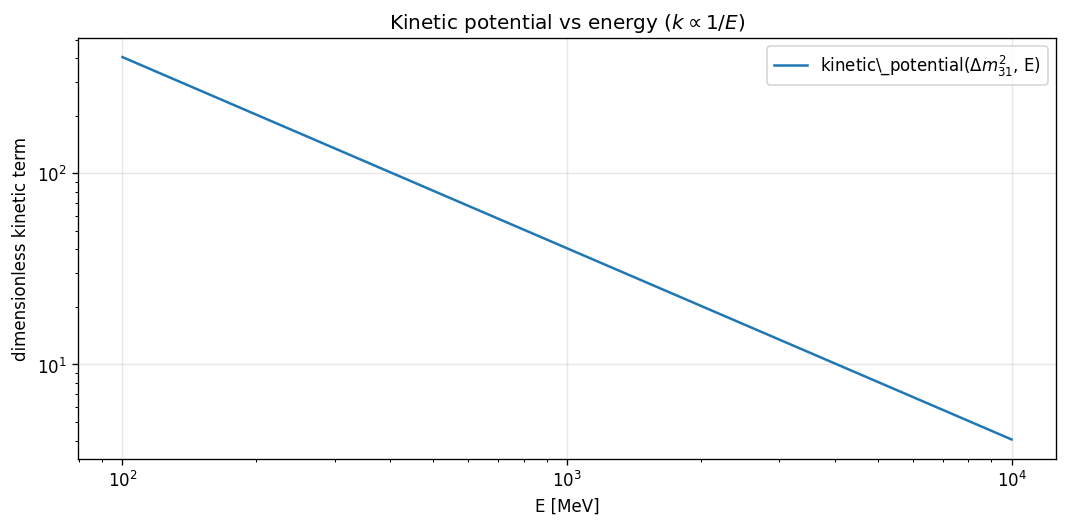

v:\output\analysis\core\core1_fig52_kinetic_potential.png


In [12]:
E_scan_MeV = torch.logspace(math.log10(100.0), math.log10(1.0e4), 60, device=context.device, dtype=context.dtype)
dm31 = float(oscillation.mass_spectrum.DeltamSq3l)

k_code = kinetic_potential(torch.tensor(dm31, dtype=context.dtype), E_scan_MeV, evolution_scale_m=constant.R_E, context=context).squeeze(-1)
k_formula = constant.R_E * 0.5 * 1.0e-12 * dm31 / to_numpy(E_scan_MeV) / constant.HBARC_MeV_m
max_diff = float(np.max(np.abs(to_numpy(k_code) - k_formula)))
print(f'max|k_code - k_formula| = {max_diff:.3e}')
assert max_diff < 1.0e-10

k_scale2 = kinetic_potential(torch.tensor(dm31, dtype=context.dtype), E_scan_MeV, evolution_scale_m=2.0 * constant.R_E, context=context).squeeze(-1)
linearity_diff = float(torch.max(torch.abs(k_scale2 - 2.0 * k_code)))
print(f'max|k(2L) - 2 k(L)|     = {linearity_diff:.3e}  (linearity in evolution_scale_m)')
assert linearity_diff < 1.0e-10

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.loglog(to_numpy(E_scan_MeV), to_numpy(k_code), label=r'kinetic\_potential($\Delta m^2_{31}$, E)')
ax.set_xlabel('E [MeV]')
ax.set_ylabel('dimensionless kinetic term')
ax.set_title(r'Kinetic potential vs energy ($k\propto 1/E$)')
ax.legend()
fig.tight_layout()
save_and_show('core1_fig52_kinetic_potential.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

### 5.3 Matter-versus-kinetic crossover scale

The density at which $V_{\rm CC}(n_e)$ equals the atmospheric kinetic term $\Delta m^2_{31}/2E\cdot\cos2\theta_{13}$ sets the two-flavour MSW resonance density for the full three-flavour Hamiltonian. Here only the *scale* is previewed: both terms are plotted together across the Earth's density range (Section 5.1) and across energy.

**Expected results:**
- The crossover density falls inside the Earth's physical density range (Section 5.1) for GeV-scale energies, consistent with Earth matter effects being relevant for atmospheric/accelerator neutrinos.
- The crossover moves to lower density as energy increases (kinetic term shrinks as $1/E$).


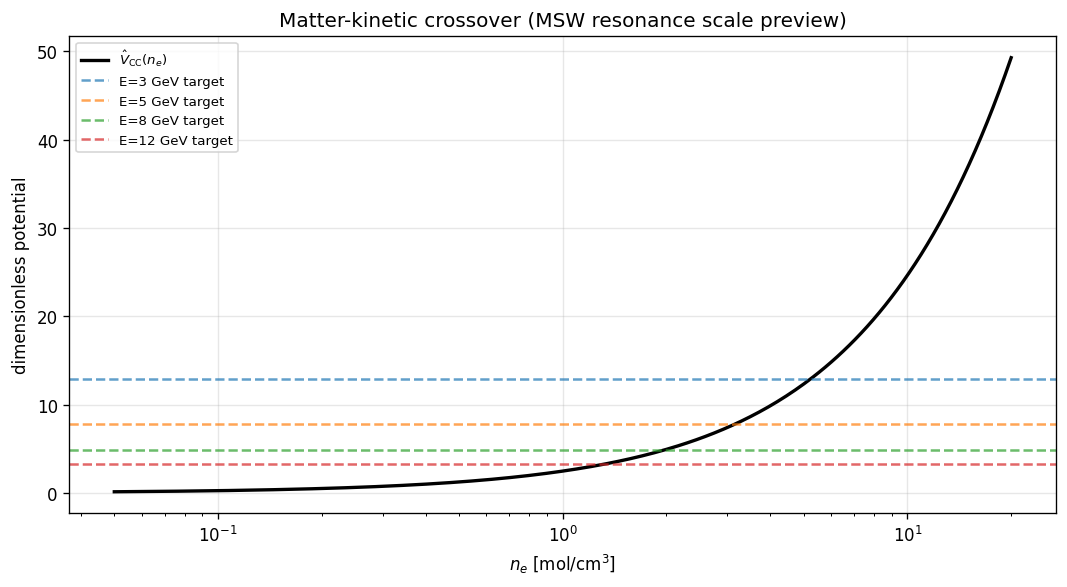

v:\output\analysis\core\core1_fig53_crossover_scale.png


,E [GeV],n_e resonance [mol/cm3]
0,3,5.239
1,5,3.143
2,8,1.965
3,12,1.310


In [13]:
theta13 = float(pmns.params.theta13)
E_ref_list = [3000.0, 5000.0, 8000.0, 12000.0]
n_e_dense = torch.logspace(math.log10(0.05), math.log10(20.0), 300, device=context.device, dtype=context.dtype)
V_cc_dense = matter_potential_cc(n_e_dense, False, evolution_scale_m=constant.R_E, context=context)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(to_numpy(n_e_dense), to_numpy(V_cc_dense), color='k', lw=2, label=r'$\hat V_{\rm CC}(n_e)$')
crossover_rows = []
for i, E_ref in enumerate(E_ref_list):
    k31 = float(kinetic_potential(torch.tensor(dm31, dtype=context.dtype), torch.tensor(E_ref, dtype=context.dtype), evolution_scale_m=constant.R_E, context=context))
    target = k31 * math.cos(2 * theta13)
    ax.axhline(target, ls='--', color=colors[i % len(colors)], alpha=0.7, label=f'E={E_ref / 1000:.0f} GeV target')
    V_at_1 = float(matter_potential_cc(torch.tensor(1.0, dtype=context.dtype), False, context=context))
    n_res = target / V_at_1
    crossover_rows.append((E_ref / 1000.0, n_res))
ax.set_xscale('log')
ax.set_xlabel(r'$n_e$ [mol/cm$^3$]')
ax.set_ylabel('dimensionless potential')
ax.set_title('Matter-kinetic crossover (MSW resonance scale preview)')
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show('core1_fig53_crossover_scale.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

crossover_table = pd.DataFrame(crossover_rows, columns=['E [GeV]', 'n_e resonance [mol/cm3]'])
display(crossover_table.style.format({'E [GeV]': '{:.0f}', 'n_e resonance [mol/cm3]': '{:.3f}'}))
assert crossover_table['n_e resonance [mol/cm3]'].between(0.3, 6.2).all()

## 6. Summary
**Expected results:**
- Every residual below is at or near floating-point precision, except the code-theory comparison in Section 5.1, which is expected to be small (<1%) but not exactly zero.
- All assertions executed in Sections 3-5 passed.

| Check | Residual |
|---|---|
| PMNS unitarity | see Section 3.1 table |
| Jarlskog vs closed form | $<10^{-12}$ |
| Antineutrino conjugation | $<10^{-12}$ |
| Vacuum projector row/col sums | $<10^{-12}$ |
| Mass-splitting consistency | $<10^{-19}\,\mathrm{eV}^2$ |
| $V_{\rm CC}$ vs rule-of-thumb | $<1\%$ |
| $V_{\rm NC}/V_{\rm CC}$ | exactly $-0.5$ |
| Kinetic potential vs formula | $<10^{-9}$ |

**Interpretation**<br>
- The PMNS matrix, its Jarlskog invariant, and its CP-conjugation convention are implemented exactly as specified in the standard parametrisation; there is no detectable numerical drift from unitarity.
- The active-sector mass-squared spectrum correctly encodes both mass orderings from a single sign convention on $\Delta m^2_{3\ell}$, with no separate code path for NO/IO.
- The charged-current matter potential reproduces an independent literature formula to sub-percent accuracy, and the neutral-current/antineutrino sign conventions are exact by construction.
- The matter-kinetic crossover density found here previews the MSW resonance condition obtained dynamically from the full three-flavour Hamiltonian.